# Protein-level multi-PTM context

For proteins measured in **`data.tsv`**, summarizes **all PTM types** in `ptm.txt` (human), not only phosphorylation.

**Inputs:** `data.tsv`, `data/ptm.txt`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print


def find_project_root() -> Path:
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (p / "data.tsv").is_file() and (p / "analyze" / "_conditions.py").is_file():
            return p
    raise FileNotFoundError("Project root not found (need data.tsv + analyze/_conditions.py).")


ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "analyze"))
from _conditions import CONDITIONS  # noqa: E402
import ptm_data as ptm  # noqa: E402

DATA_PATH = ROOT / "data.tsv"
PTM_PATH = ROOT / "data" / "ptm.txt"
PPIC_PATH = ROOT / "data" / "ppic" / "edges.tsv"
KSEA_LONG = ROOT / "output" / "analyze" / "ksea_prerank_long.tsv"

THR = float(-np.log10(0.05))
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 40)

print("ROOT =", ROOT)


ROOT = /Users/ph/Documents/phospho_mhg_anno


In [2]:
DATA = pd.read_csv(DATA_PATH, sep='\t', low_memory=False)
df_ptm = ptm.load_ptm(PTM_PATH)
df_h = ptm.filter_human(df_ptm)
up = set(DATA['proteinid'].astype(str).str.upper().str.strip())
gn = set(DATA['geneid'].astype(str).str.upper().str.strip())
sub_u = df_h['substrate_UniProtAC'].astype(str).str.upper().str.strip()
sub_g = df_h['substrate_genename'].astype(str).str.upper().str.strip()
mask = sub_u.isin(up) | sub_g.isin(gn)
df_m = df_h.loc[mask].copy()
print('PTM rows touching measured proteins (human):', len(df_m))


PTM rows touching measured proteins (human): 47489


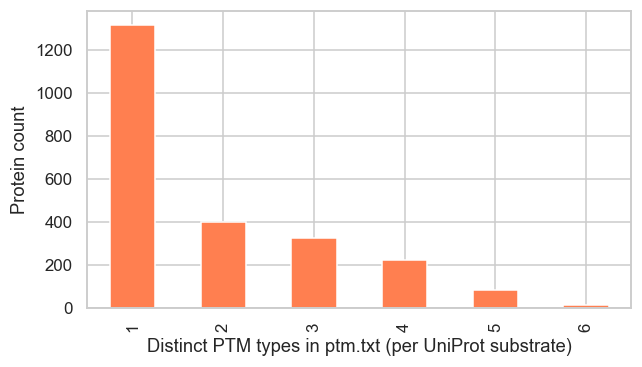

In [3]:
by_prot = df_m.groupby('substrate_UniProtAC')['ptm_type'].nunique().rename('n_ptm_types')
fig, ax = plt.subplots(figsize=(6, 3.5))
by_prot.value_counts().sort_index().plot(kind='bar', ax=ax, color='coral')
ax.set_xlabel('Distinct PTM types in ptm.txt (per UniProt substrate)')
ax.set_ylabel('Protein count')
fig.tight_layout()
plt.show()


## Binary heatmap: top variable genes × PTM type (human, measured proteins)

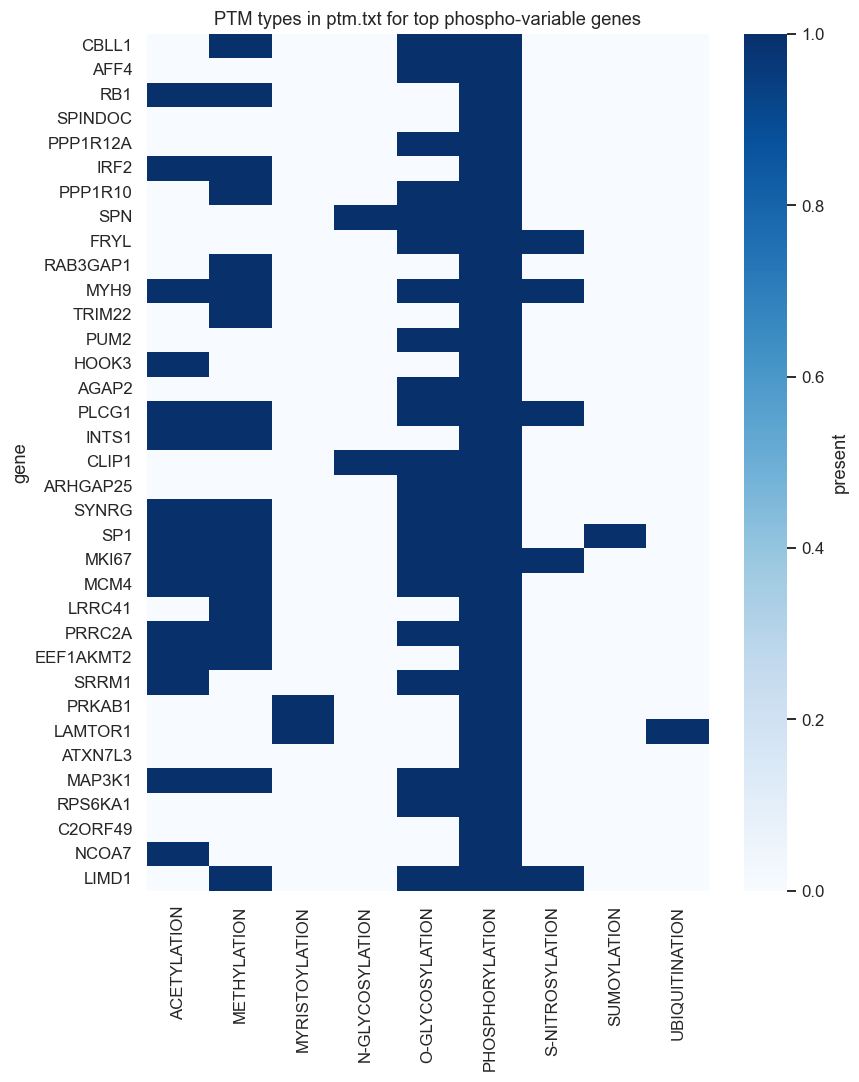

In [4]:
sc_mat = []
for c in CONDITIONS:
    log2 = pd.to_numeric(DATA[c.log2fc_col], errors='coerce')
    nlp = pd.to_numeric(DATA[c.neglogp_col], errors='coerce')
    sc_mat.append((log2 * nlp).abs())
DATA['_gmax'] = pd.concat(sc_mat, axis=1).max(axis=1)
genes_u = DATA['geneid'].astype(str).str.upper()
gsc = DATA.groupby(genes_u, as_index=True)['_gmax'].max().sort_values(ascending=False)
top_genes = gsc.head(35).index.tolist()
ptm_types = sorted(df_m['ptm_type'].astype(str).unique())
rec = []
for g in top_genes:
    sub = df_m[df_m['substrate_genename'].astype(str).str.upper() == g]
    row = {t: int(t in set(sub['ptm_type'].astype(str))) for t in ptm_types}
    row['gene'] = g
    rec.append(row)
wide = pd.DataFrame(rec).set_index('gene')
fig, ax = plt.subplots(figsize=(max(8, len(ptm_types) * 0.35), 10))
sns.heatmap(wide, ax=ax, cmap='Blues', cbar_kws={'label': 'present'})
ax.set_title('PTM types in ptm.txt for top phospho-variable genes')
fig.tight_layout()
plt.show()


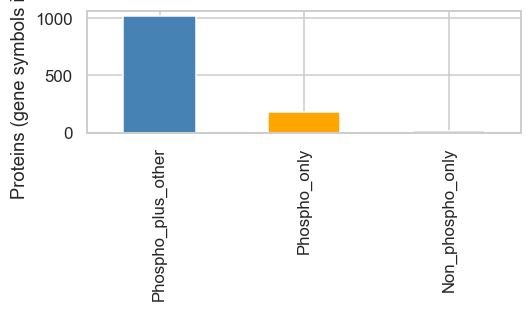

In [5]:
# Phospho-only vs multi-PTM proteins (among measured)
df_m['_g'] = df_m['substrate_genename'].astype(str).str.upper()
agg = df_m.groupby('_g')['ptm_type'].apply(lambda s: frozenset(s.astype(str)))
cats = []
for fs in agg:
    has_p = 'PHOSPHORYLATION' in fs
    n = len(fs)
    if has_p and n == 1:
        cats.append('Phospho_only')
    elif has_p:
        cats.append('Phospho_plus_other')
    else:
        cats.append('Non_phospho_only')
vc2 = pd.Series(cats).value_counts()
fig, ax = plt.subplots(figsize=(5, 3))
vc2.plot(kind='bar', ax=ax, color=['steelblue', 'orange', 'gray'])
ax.set_ylabel('Proteins (gene symbols in ptm)')
fig.tight_layout()
plt.show()
